---
title: "🔄 CNN to Inferno Pipeline"
author: "Maksim Ohvrill"
date: "5/1/2025"
format:
  html:
    toc: true
    toc-location: right
    code-fold: true
bibliography: references.bib
csl: ieee-with-url.csl
jupyter: Python
---

> Example on CNN with Inferno Pipeline Example for a Predictions


## **Pipeline demonstration:**

Prediction Result of CNN

Label   Logit  Confidence  Prediction
   Effusion  0.2818      0.5700           1
Atelectasis -0.2889      0.4283           1

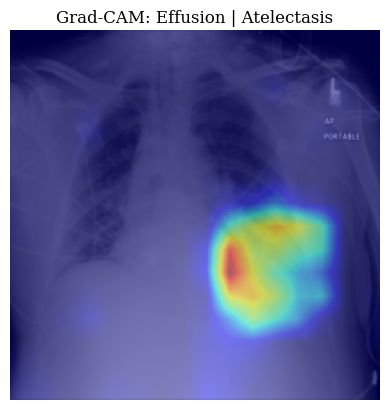

🚀Params for Inferno

{
    'input_csv': 'data/inferno/calibration_test.csv',
    'model_path': 'data/inferno/combinedML50/learnt.rds',
    'input_values': {
        'AGE': [48],
        'GENDER': ['M'],
        'VP': ['AP'],
        'LOGIT_EFFUSION': [0.2818],
        'LOGIT_ATELECTASIS': [-0.2889],
        'LABEL_EFFUSION': [0, 1],
        'LABEL_ATELECTASIS': [0, 1]
    },
    'predictors': ['AGE', 'GENDER', 'VP', 'LOGIT_EFFUSION', 'LOGIT_ATELECTASIS'],
    'predictands': ['LABEL_EFFUSION', 'LABEL_ATELECTASIS']
}


Registered doParallelSNOW with 10 workers

Closing connections to cores.

Single Patient Clinical Decision Report
Patient Predictor Data (Features Only):
  AGE GENDER VP LOGIT_EFFUSION LOGIT_ATELECTASIS
1  48      M AP         0.2818           -0.2889

Predicted Probabilities for Outcomes (%):
  Outcome Probability
1   E0 A0        25.0
2   E1 A0        36.2
3   E0 A1        20.0
4   E1 A1        18.8

Expected Utilities for Clinical Actions:
                        Action Expected_Utility
1             Send to Hospital              0.5
2     Start Drainage Treatment              0.4
3 Start Bronchodilator Therapy              0.6
4              Supportive Care              0.5
5              Observe Closely              0.5

Recommended Clinical Action:
Start Bronchodilator Therapy

🧠 Recommendation Check
✅ Prediction 1 is reliable (±17.3%).
⚠️ Prediction 2 shows moderate uncertainty (±25.8%). Consider reviewing.
✅ Prediction 3 is reliable (±19.5%).
✅ Prediction 4 is reliable (±13.2%

In [1]:
import os
from pathlib import Path
from rich.console import Console
from CNN import run_inferno_prediction, predict_from_image_path

# Move the working directory to the parent folder
WORKDIR = Path("/home/maxvill/InfernoCalibNet")
os.chdir(WORKDIR)

# Initialize console for rich printing
console = Console()

# Retrieving logits from CNN for a given image
(logit_efu, logit_ate), *_ = predict_from_image_path(
    image_path="/home/maxvill/InfernoCalibNet/data/raw/xrays/xrays6/00012236_010.png"
)

predictor_sets = [
    {
        "LOGIT_EFFUSION": 0.2818,
        "LOGIT_ATELECTASIS": -0.2889,
        "AGE": 48,
        "VP": "AP",
        "GENDER": "M",
    }
]

predictand_input = {"LABEL_EFFUSION": [0, 1], "LABEL_ATELECTASIS": [0, 1]}

# Running Infeno prediction
result = run_inferno_prediction(
    predictor_sets=predictor_sets, predictand_input=predictand_input
)


## 🧠 What is display?: Inferno Prediction Workflow

This output illustrates how the Inferno framework generates calibrated probabilistic predictions for clinical outcomes by combining CNN derived logits with auxiliary patient data.

### 🔀 Workflow Overview

1. **Image Processing & Logit Extraction**
   A chest x-ray image is passed through a CNN, which outputs raw logits for conditions such as Effusion and Atelectasis. These serve as structured summaries of the image.

2. **GradCAM Heatmap Generation**
   A GradCAM visualisation is created to highlight regions most influential to the CNNs decision, aiding interpretability.

3. **Predictor Set Construction**
   Patient specific predictor sets are prepared combining:

   * CNN logits
   * Auxiliary data (e.g., age, gender, view position)

4. **Inferno Input Specification**
   Predictors and predictands are defined:

   ```json
   {
       "input_csv": "data/inferno/calibration_test.csv",
       "model_path": "data/inferno/combinedML50/learnt.rds",
       "input_values": {
           "AGE": [48],
           "GENDER": ["M"],
           "VP": ["AP"],
           "LOGIT_EFFUSION": [0.2818],
           "LOGIT_ATELECTASIS": [-0.2889],
           "LABEL_EFFUSION": [0, 1],
           "LABEL_ATELECTASIS": [0, 1]
       },
       "predictors": ["AGE", "GENDER", "VP", "LOGIT_EFFUSION", "LOGIT_ATELECTASIS"],
       "predictands": ["LABEL_EFFUSION", "LABEL_ATELECTASIS"]
   }
   ```

5. **Prediction Execution**

## 📊 Interpreting the Output

### Prediction Result of CNN

| Label       | Logit   | Confidence | Prediction |
| ----------- | ------- | ---------- | ---------- |
| Effusion    | 0.2818  | 0.5700     | 1          |
| Atelectasis | -0.2889 | 0.4283     | 1          |

### Predicted Probabilities for Outcomes (%)

| Outcome | Probability |
| ------- | ----------- |
| E0 A0   | 25.0        |
| E1 A0   | 36.2        |
| E0 A1   | 20.0        |
| E1 A1   | 18.8        |

### Expected Utilities for Clinical Actions

| Action                       | Expected Utility |
| ---------------------------- | ---------------- |
| Send to Hospital             | 0.5              |
| Start Drainage Treatment     | 0.4              |
| Start Bronchodilator Therapy | 0.6              |
| Supportive Care              | 0.5              |
| Observe Closely              | 0.5              |

**🚀 Recommended Action:** Start Bronchodilator Therapy

### 🧠 Recommendation Check

* ✅ Prediction 1 is reliable (±17.3%)
* ⚠️ Prediction 2 shows moderate uncertainty (±25.8%)
* ✅ Prediction 3 is reliable (±19.5%)
* ✅ Prediction 4 is reliable (±13.2%)


## **🧼 Probability Function**

For each combination of predictors $x$ and predictands $y$, Inferno estimates the following probability:

$$
P(y \mid x, \text{data})
$$

Explicitly, for example:

$$
P(\text{label-effusion}, \text{label-atelectasis} \mid \text{logit-effusion}, \text{age}, \text{gender}, \text{vp})
$$

where:

* $x$ includes CNN logits (e.g., *logit-effusion*) and optionally other auxiliary variables (e.g., *age*, *gender*, *vp*),
* $y$ includes the labels to predict (e.g., *label-effusion*, *label-atelectasis*).

This structured output supports clinician interpretation by combining model predictions with uncertainty estimates and actionable recommendations.